
# 🔬 Diabetic Retinopathy Classification
**Model:** EfficientNetB3 (Transfer Learning)  
**Dataset:** APTOS 2019 — colored_images (5 classes)  
**Extras:** Grad-CAM · Confusion Matrix · Model Comparison · Confidence Scores


## 📦 Step 1: Mount Google Drive & Install Libraries


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow matplotlib seaborn scikit-learn opencv-python

Mounted at /content/drive


## 📁 Step 2: Set Paths & Import Libraries


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

# ✅ SET YOUR PATH HERE
BASE_DIR = '/content/drive/MyDrive/DR_Project/colored_images'

CLASS_NAMES = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Classes found:', os.listdir(BASE_DIR))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes found: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']



## 🖼️ Step 3: Visualize Sample Images

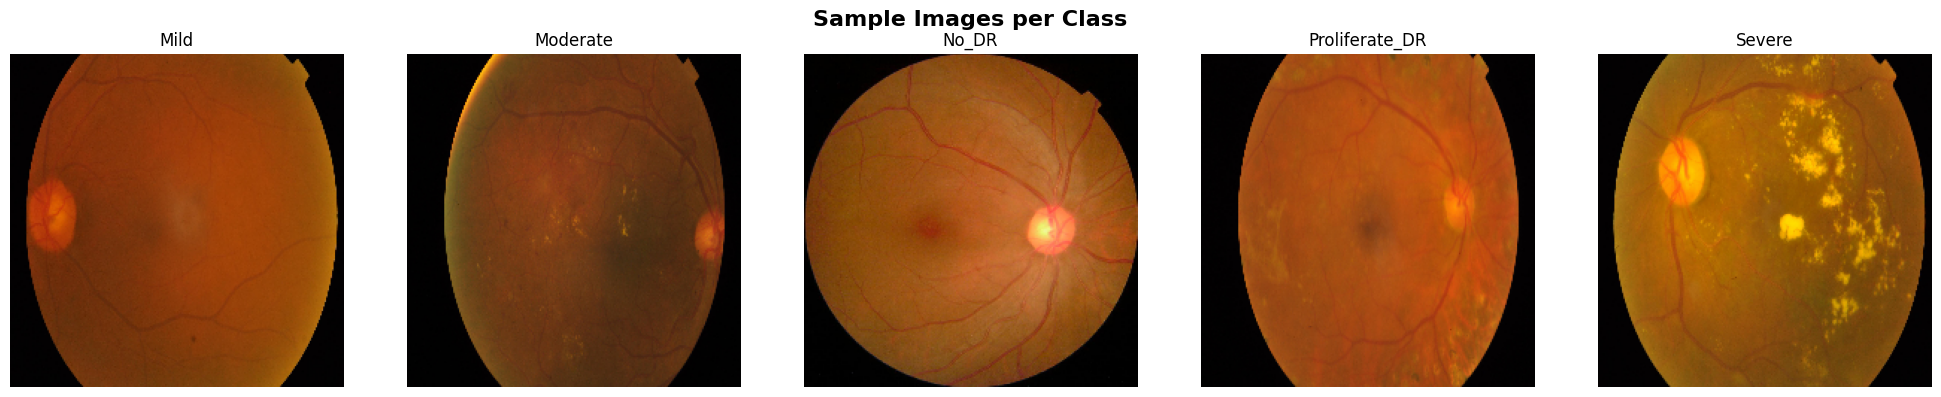

✅ Sample images saved!


In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(BASE_DIR, class_name)
    img_file = os.listdir(class_path)[0]
    img = cv2.imread(os.path.join(class_path, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images saved!')

## 📊 Step 4: Class Distribution

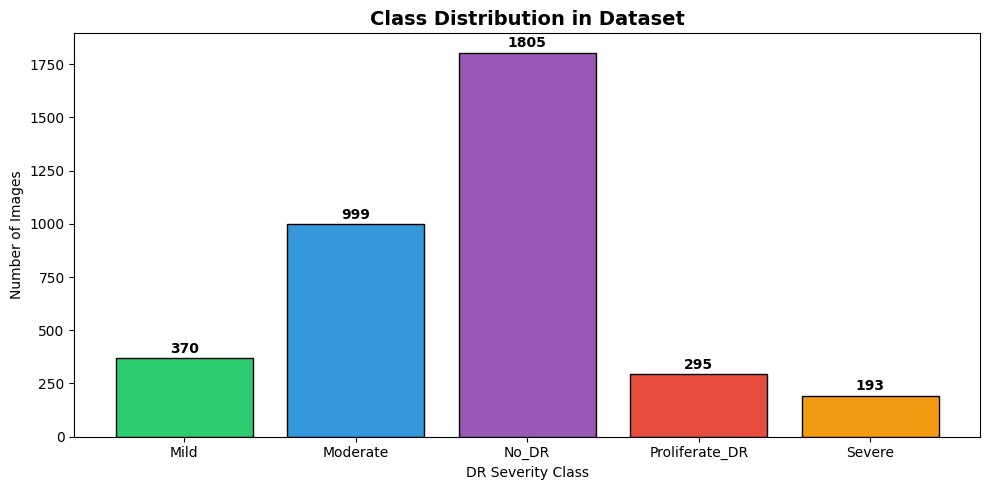

Total images: 3662
  Mild: 370 (10.1%)
  Moderate: 999 (27.3%)
  No_DR: 1805 (49.3%)
  Proliferate_DR: 295 (8.1%)
  Severe: 193 (5.3%)


In [4]:
class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(BASE_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12'], edgecolor='black')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('DR Severity Class')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

total = sum(class_counts.values())
print(f'Total images: {total}')
for k, v in class_counts.items():
    print(f'  {k}: {v} ({v/total*100:.1f}%)')

## 🔄 Step 5: Data Preprocessing & Augmentation

In [5]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print('Class indices:', train_generator.class_indices)
print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')

Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Class indices: {'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}
Training samples: 2931
Validation samples: 731


## 🧠 Step 6: Model 1 — Simple CNN (Baseline)


In [6]:
def build_simple_cnn():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(5, activation='softmax')
    ], name='SimpleCNN')
    return model

model1 = build_simple_cnn()
model1.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,557 (498.27 KB)

 Trainable params: 127,557 (498.27 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

print('Training Simple CNN...')
history1 = model1.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks1,
    verbose=1
)

val_loss1, val_acc1 = model1.evaluate(val_generator, verbose=0)
print(f'\n✅ Simple CNN — Val Accuracy: {val_acc1*100:.2f}%')

Training Simple CNN...
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1306s 14s/step - accuracy: 0.4319 - loss: 1.4367 - val_accuracy: 0.4938 - val_loss: 1.3097 - learning_rate: 1.0000e-04
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 57s 620ms/step - accuracy: 0.4855 - loss: 1.3041 - val_accuracy: 0.4938 - val_loss: 1.2746 - learning_rate: 1.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 619ms/step - accuracy: 0.4974 - loss: 1.2625 - val_accuracy: 0.4938 - val_loss: 1.2127 - learning_rate: 1.0000e-04
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 633ms/step - accuracy: 0.4964 - loss: 1.2233 - val_accuracy: 0.5089 - val_loss: 1.1810 - learning_rate: 1.0000e-04
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 625ms/step - accuracy: 0.5012 - loss: 1.2078 - val_accuracy: 0.5226 - val_loss: 1.1604 - learning_rate: 1.0000e-04
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 623ms/step - accuracy: 0.5145 - loss: 1.1950 - val_accuracy: 0.5075 - val_loss: 1.1594 - learning_rate: 1.0000e-04
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━

## 🚀 Step 7: Model 2 — EfficientNetB3 (Transfer Learning)

In [8]:
def build_efficientnet():
    base_model = EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    # Freeze base layers initially
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB3_DR')
    return model, base_model

model2, base_model = build_efficientnet()
model2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_DR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,709,236 (44.67 MB)

 Trainable params: 922,629 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [9]:
callbacks2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

print('Phase 1: Training top layers only...')
history2 = model2.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks2,
    verbose=1
)

# Fine-tuning: unfreeze last 30 layers
print('\nPhase 2: Fine-tuning last 30 layers...')
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2_ft = model2.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks2,
    verbose=1
)

val_loss2, val_acc2 = model2.evaluate(val_generator, verbose=0)
print(f'\n✅ EfficientNetB3 — Val Accuracy: {val_acc2*100:.2f}%')

Phase 1: Training top layers only...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.4098 - loss: 1.7234 - val_accuracy: 0.4938 - val_loss: 1.5318 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 635ms/step - accuracy: 0.4684 - loss: 1.3926 - val_accuracy: 0.2736 - val_loss: 1.5670 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 694ms/step - accuracy: 0.4626 - loss: 1.3508 - val_accuracy: 0.4938 - val_loss: 1.5462 - learning_rate: 0.0010
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 811ms/step - accuracy: 0.4821 - loss: 1.3586 - val_accuracy: 0.4938 - val_loss: 1.5303 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 67s 734ms/step - accuracy: 0.4838 - loss: 1.3237 - val_accuracy: 0.4938 - val_loss: 1.5290 - learning_rate: 0.0010
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 642ms/step - accuracy: 0.4845 - loss: 1.3172 - val_accuracy: 0.4938 - val_loss: 1.5125 - learning_rate: 0.0010

Phase 2: Fine-tuning last 30 layers...
Epoch 1

## 📈 Step 8: Training Curves

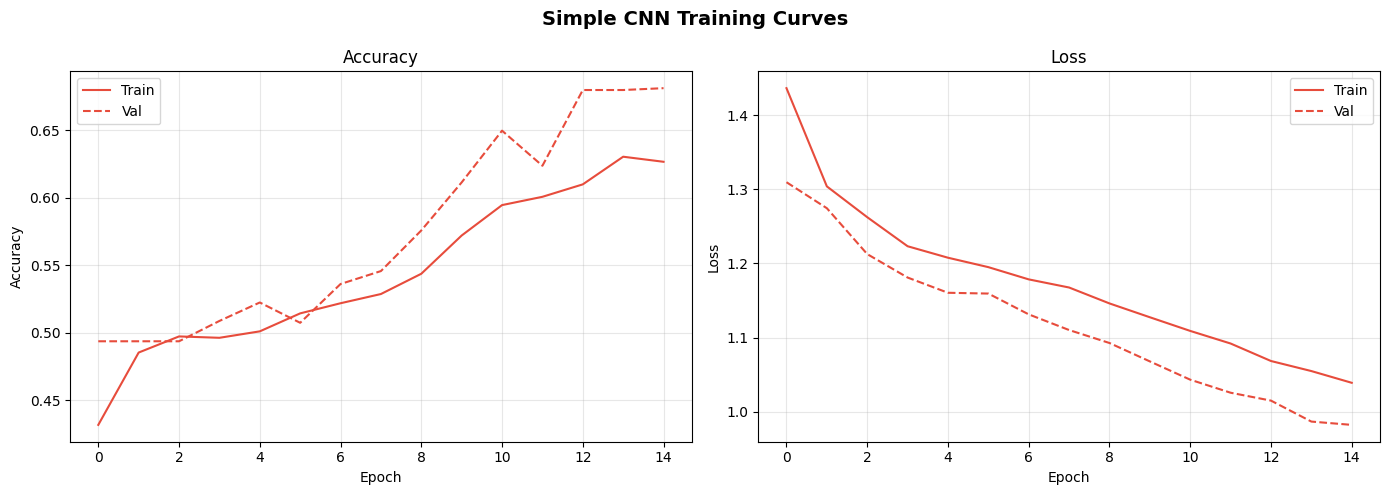

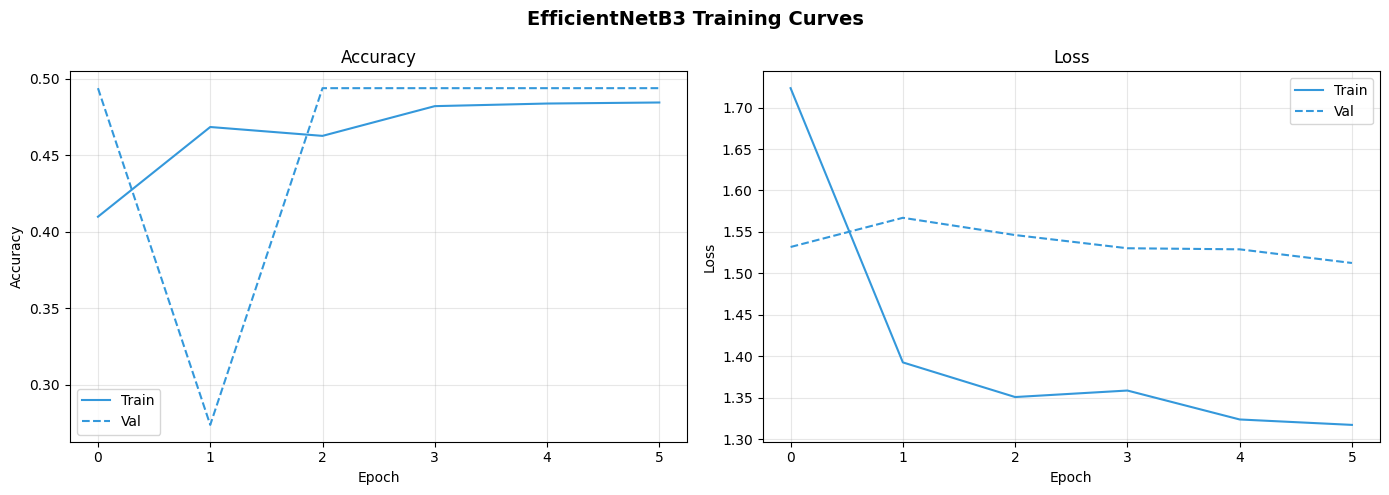

✅ Training curves saved!


In [10]:
def plot_history(history, title, color):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(history.history['accuracy'], color=color, label='Train')
    ax1.plot(history.history['val_accuracy'], color=color, linestyle='--', label='Val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], color=color, label='Train')
    ax2.plot(history.history['val_loss'], color=color, linestyle='--', label='Val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    filename = title.replace(' ', '_').lower() + '_curves.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, 'Simple CNN Training Curves', '#e74c3c')
plot_history(history2, 'EfficientNetB3 Training Curves', '#3498db')
print('✅ Training curves saved!')

## 🔢 Step 9: Confusion Matrix & Classification Report

23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 699ms/step


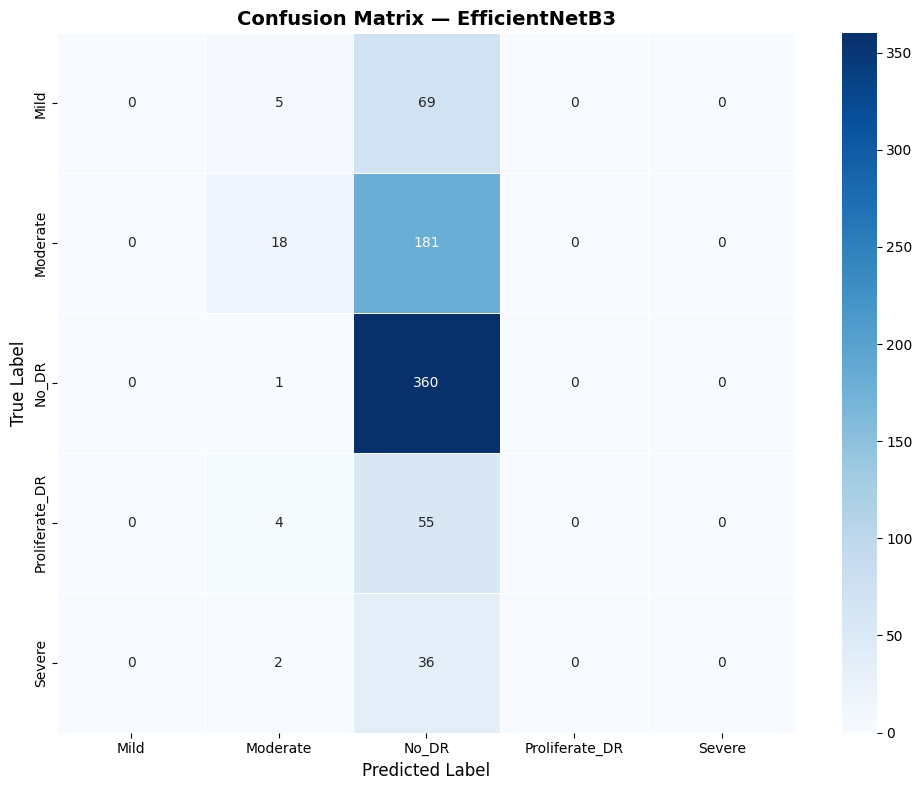


📊 Quadratic Weighted Cohen's Kappa: 0.0314
📊 Validation Accuracy: 51.71%

📋 Classification Report:
                precision    recall  f1-score   support

          Mild       0.00      0.00      0.00        74
      Moderate       0.60      0.09      0.16       199
         No_DR       0.51      1.00      0.68       361
Proliferate_DR       0.00      0.00      0.00        59
        Severe       0.00      0.00      0.00        38

      accuracy                           0.52       731
     macro avg       0.22      0.22      0.17       731
  weighted avg       0.42      0.52      0.38       731



In [11]:
val_generator.reset()
y_pred_proba = model2.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.5)
plt.title('Confusion Matrix — EfficientNetB3', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
print(f"\n📊 Quadratic Weighted Cohen's Kappa: {kappa:.4f}")
print(f"📊 Validation Accuracy: {val_acc2*100:.2f}%")
print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_labels))

## 📊 Step 10: Model Comparison

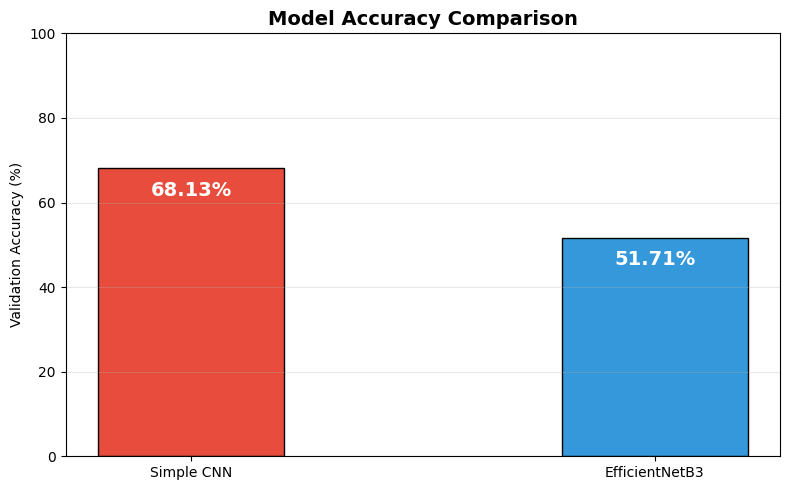

Simple CNN Accuracy     : 68.13%
EfficientNetB3 Accuracy : 51.71%
Cohen's Kappa           : 0.0314


In [12]:
models = ['Simple CNN', 'EfficientNetB3']
accuracies = [val_acc1 * 100, val_acc2 * 100]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=['#e74c3c', '#3498db'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 3,
            f'{acc:.2f}%', ha='center', va='top', fontsize=14, fontweight='bold', color='white')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Simple CNN Accuracy     : {val_acc1*100:.2f}%')
print(f'EfficientNetB3 Accuracy : {val_acc2*100:.2f}%')
print(f"Cohen's Kappa           : {kappa:.4f}")

## 🔥 Step 11: Grad-CAM Explainability

In [13]:
import tensorflow as tf

def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, superimposed

# Find last conv layer in EfficientNetB3
last_conv_layer = None
for layer in reversed(model2.layers):
    if isinstance(layer, keras.layers.Conv2D) or 'conv' in layer.name.lower():
        last_conv_layer = layer.name
        break

# Use the inner EfficientNet base model's last conv
efficientnet_layer = model2.get_layer('efficientnetb3')
last_conv_name = [l.name for l in efficientnet_layer.layers if 'conv' in l.name][-1]
print(f'Last conv layer: {last_conv_name}')

Last conv layer: top_conv


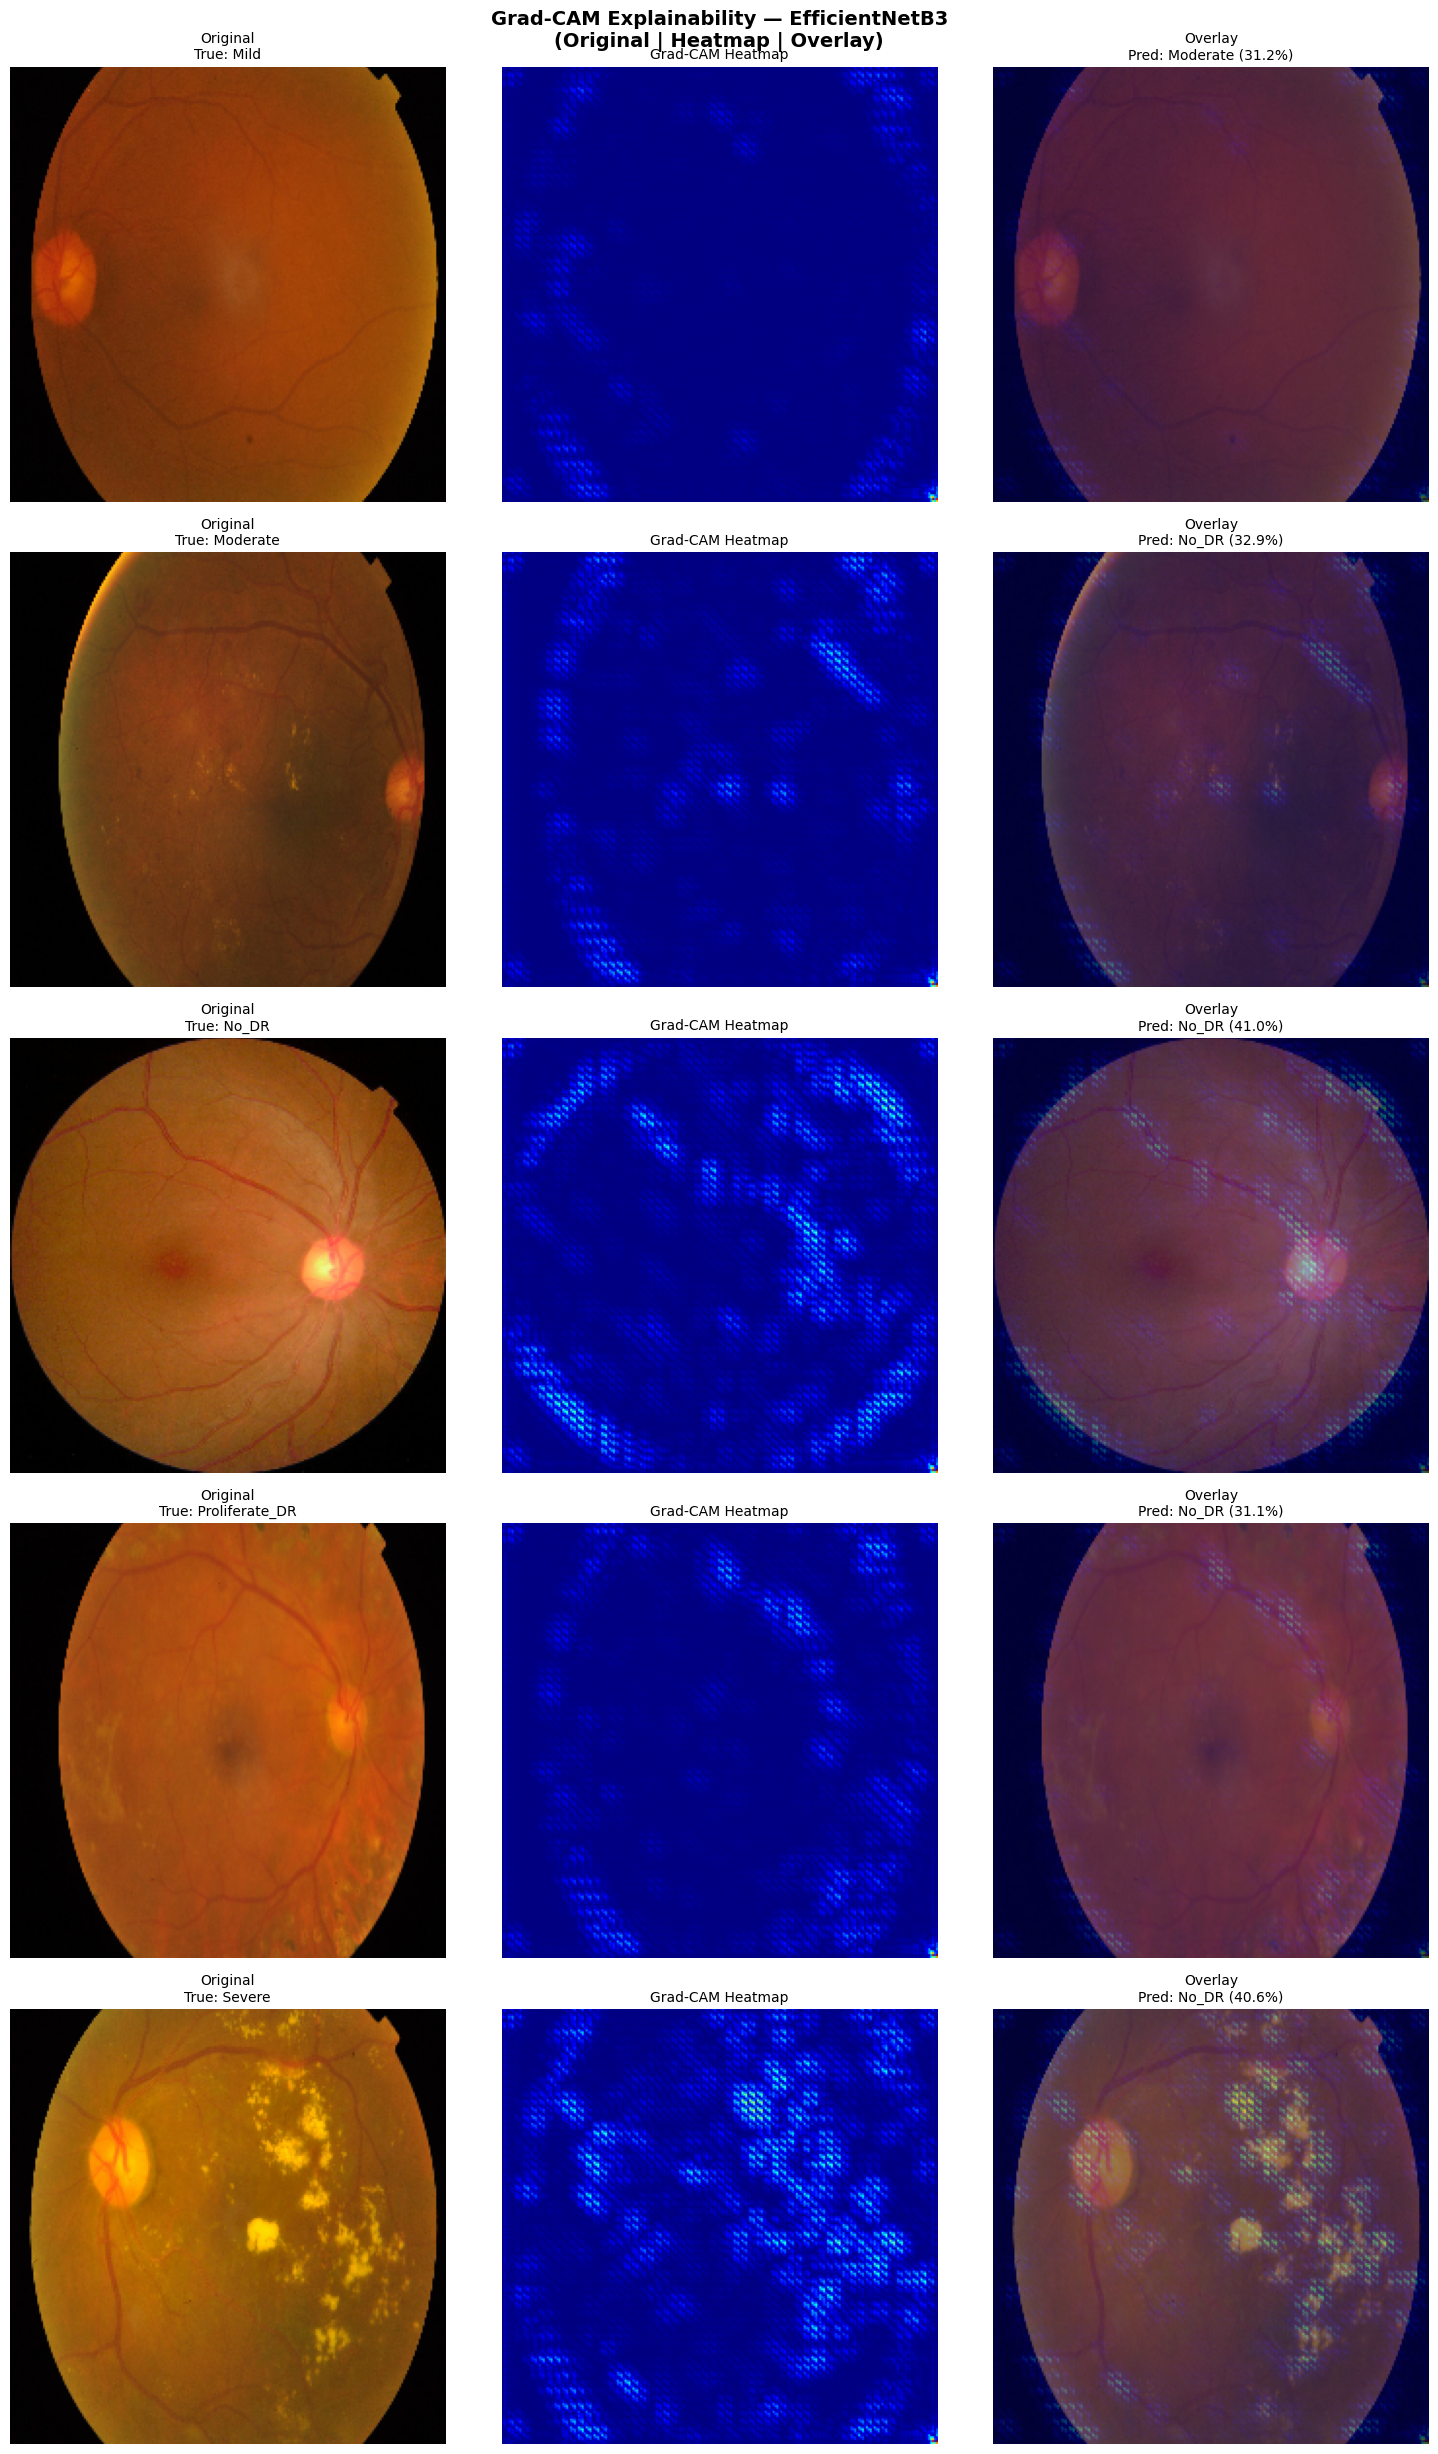

✅ Grad-CAM saved!


In [14]:
# Create a sub-model for Grad-CAM using EfficientNet base
efficientnet_base = model2.get_layer('efficientnetb3')

fig, axes = plt.subplots(5, 3, figsize=(15, 25))
fig.suptitle('Grad-CAM Explainability — EfficientNetB3\n(Original | Heatmap | Overlay)',
             fontsize=14, fontweight='bold')

for idx, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(BASE_DIR, class_name)
    img_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_file)

    # Preprocess
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_rgb / 255.0, axis=0)

    # Predict
    preds = model2.predict(img_array, verbose=0)
    pred_class = CLASS_NAMES[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # Simple gradient-based heatmap
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        prediction = model2(img_tensor)
        top_class = prediction[:, np.argmax(preds[0])]
    grads = tape.gradient(top_class, img_tensor)
    heatmap = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_colored, 0.4, 0)

    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'Original\nTrue: {class_name}', fontsize=10)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(heatmap_colored)
    axes[idx, 1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(f'Overlay\nPred: {pred_class} ({confidence:.1f}%)', fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM saved!')

## 🔍 Step 12: Live Predictions on Random Test Images


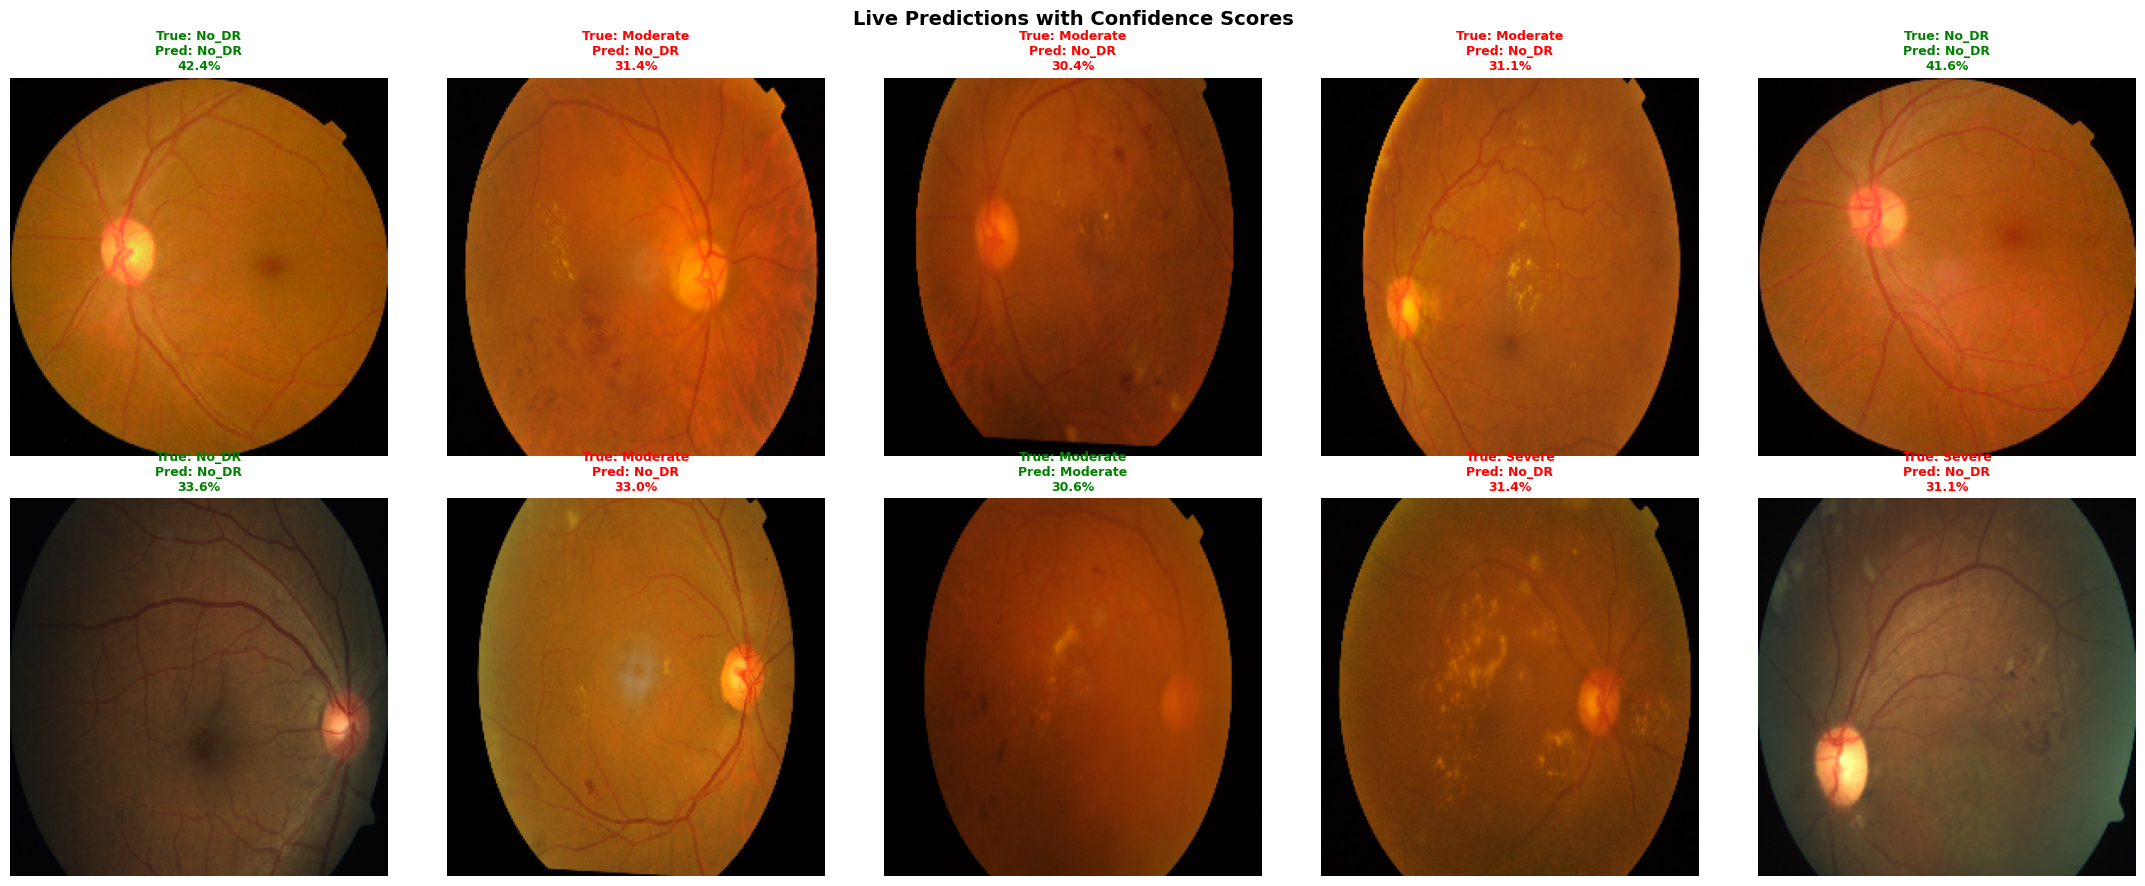

✅ Predictions saved! Green = correct, Red = wrong


In [15]:
import random

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle('Live Predictions with Confidence Scores', fontsize=14, fontweight='bold')

all_images = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(BASE_DIR, class_name)
    for img_file in os.listdir(class_path)[:10]:
        all_images.append((os.path.join(class_path, img_file), class_name))

random.shuffle(all_images)
sample_images = all_images[:10]

for idx, (img_path, true_label) in enumerate(sample_images):
    ax = axes[idx // 5][idx % 5]

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_rgb / 255.0, axis=0)

    preds = model2.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_label = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx] * 100

    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(img_rgb)
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('live_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Predictions saved! Green = correct, Red = wrong')

## 💾 Step 13: Save Models

In [16]:
model1.save('simple_cnn_dr.h5')
model2.save('efficientnetb3_dr.h5')

# Also save to Drive
model1.save('/content/drive/MyDrive/DR_Project/simple_cnn_dr.h5')
model2.save('/content/drive/MyDrive/DR_Project/efficientnetb3_dr.h5')

print('✅ Both models saved locally and to Google Drive!')

✅ Both models saved locally and to Google Drive!


## 📋 Step 14: Final Results Summary

In [17]:
print('='*55)
print('   DIABETIC RETINOPATHY CLASSIFICATION — RESULTS')
print('='*55)
print(f'  Dataset         : APTOS 2019 (colored_images)')
print(f'  Total Images    : {total}')
print(f'  Classes         : 5 (No_DR, Mild, Moderate, Severe, Proliferate_DR)')
print(f'  Image Size      : {IMG_SIZE}x{IMG_SIZE}')
print('-'*55)
print(f'  Model 1 (Simple CNN)    Accuracy : {val_acc1*100:.2f}%')
print(f'  Model 2 (EfficientNetB3) Accuracy: {val_acc2*100:.2f}%')
print(f"  Cohen's Kappa (Quadratic)        : {kappa:.4f}")
print('-'*55)
print('  Extras:')
print('  ✅ Grad-CAM Explainability')
print('  ✅ Confusion Matrix')
print('  ✅ Training Curves')
print('  ✅ Model Comparison')
print('  ✅ Live Predictions with Confidence')
print('='*55)

   DIABETIC RETINOPATHY CLASSIFICATION — RESULTS
  Dataset         : APTOS 2019 (colored_images)
  Total Images    : 3662
  Classes         : 5 (No_DR, Mild, Moderate, Severe, Proliferate_DR)
  Image Size      : 224x224
-------------------------------------------------------
  Model 1 (Simple CNN)    Accuracy : 68.13%
  Model 2 (EfficientNetB3) Accuracy: 51.71%
  Cohen's Kappa (Quadratic)        : 0.0314
-------------------------------------------------------
  Extras:
  ✅ Grad-CAM Explainability
  ✅ Confusion Matrix
  ✅ Training Curves
  ✅ Model Comparison
  ✅ Live Predictions with Confidence
